In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))
df_original = df.copy()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.shape

(7043, 21)

In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop(
    'customerID',
    axis=1,
    inplace=True
)

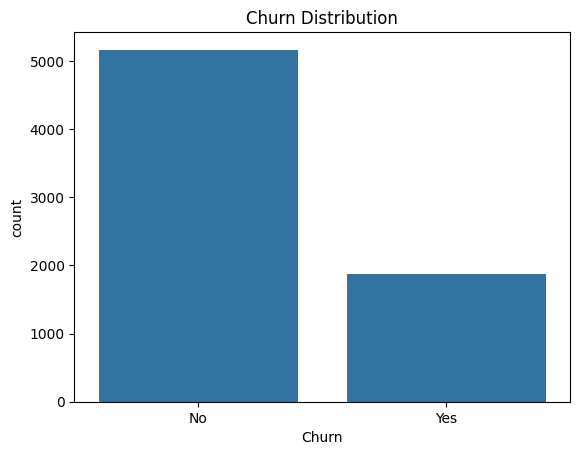

In [ ]:
sns.countplot(
    x='Churn',
    data=df
)

plt.title("Churn Distribution")
plt.show()

In [ ]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [ ]:
X = df.drop(
    'Churn_Yes',
    axis=1
)

y = df['Churn_Yes']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
pred = model.predict(
    X_test
)

In [ ]:
accuracy = accuracy_score(
    y_test,
    pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7889125799573561


In [ ]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



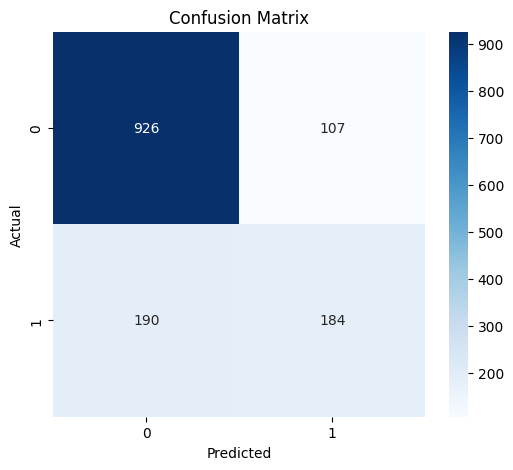

In [ ]:
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

AUC Score: 0.8176693188936226


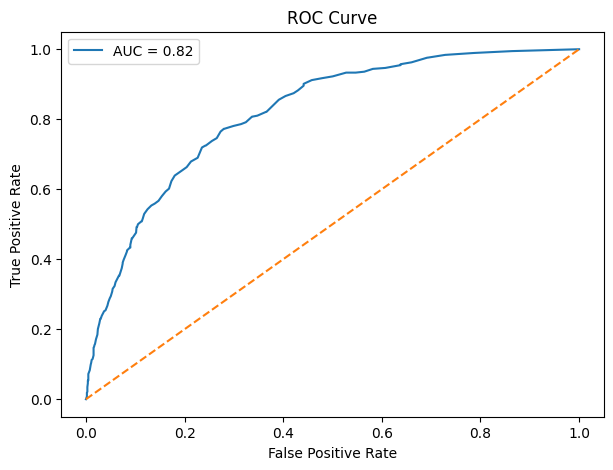

In [ ]:
y_prob = model.predict_proba(
    X_test
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

print("AUC Score:", roc_auc)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    feature_importance.head(10)
)

                           Feature  Importance
3                     TotalCharges    0.174454
1                           tenure    0.164773
2                   MonthlyCharges    0.154132
25               Contract_Two year    0.059141
28  PaymentMethod_Electronic check    0.038563
10     InternetService_Fiber optic    0.037743
24               Contract_One year    0.030802
13              OnlineSecurity_Yes    0.030568
4                      gender_Male    0.025842
19                 TechSupport_Yes    0.023328


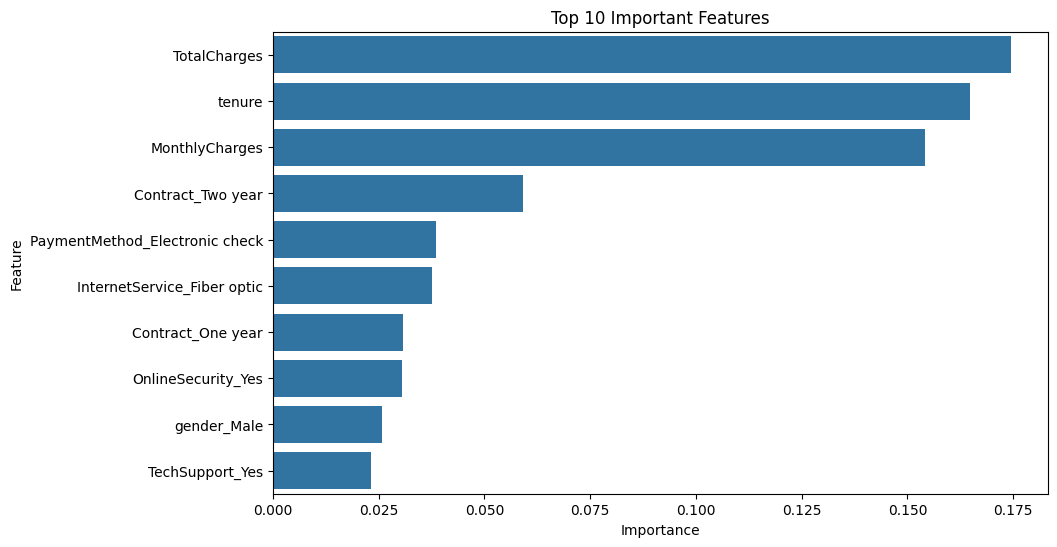

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [ ]:
models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),

    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "Random Forest":
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    )
}

In [ ]:
results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    results.append([
        name,
        accuracy_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Recall',
        'F1'
    ]
)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy    Recall        F1
0  Logistic Regression  0.727790  0.796791  0.608784
1        Decision Tree  0.732054  0.491979  0.493960
2        Random Forest  0.788913  0.491979  0.553383


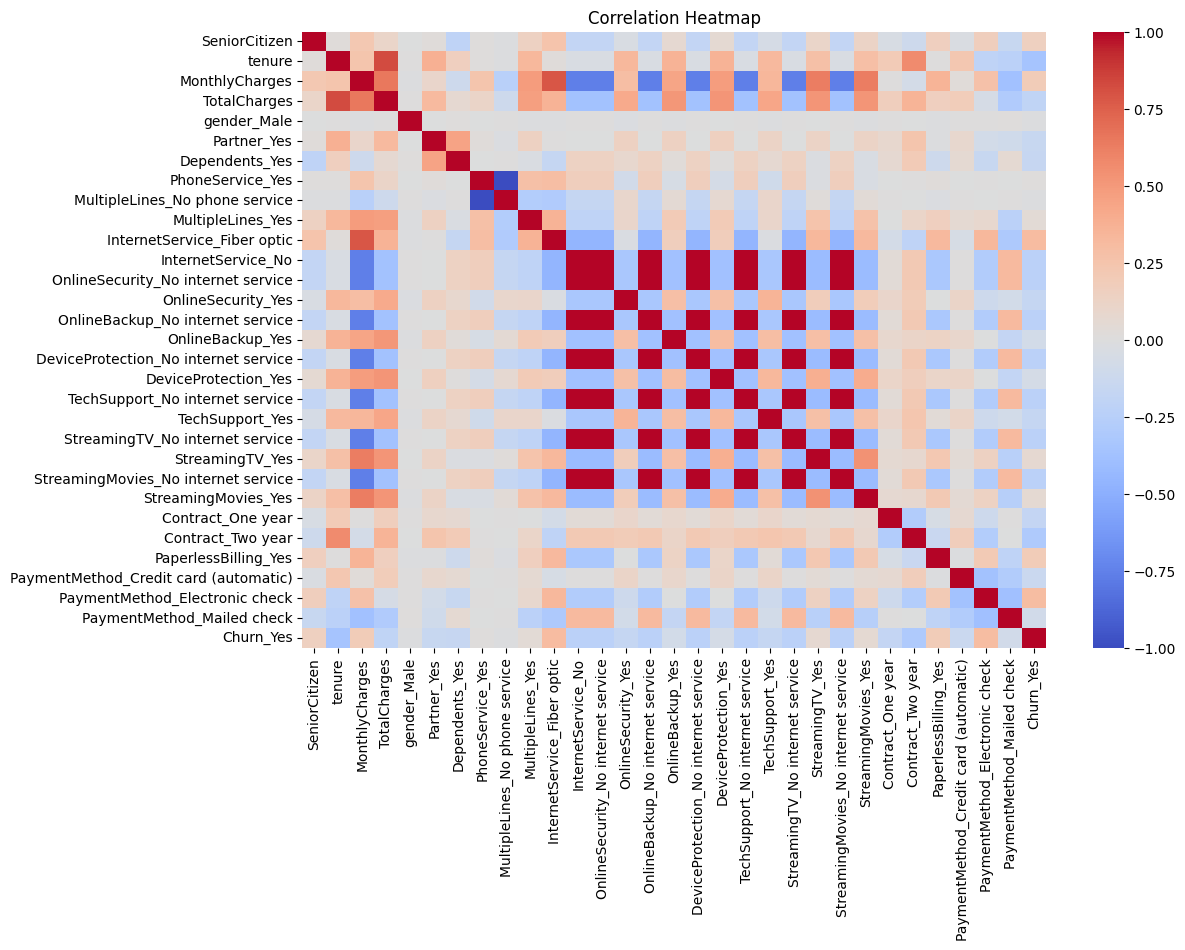

In [ ]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

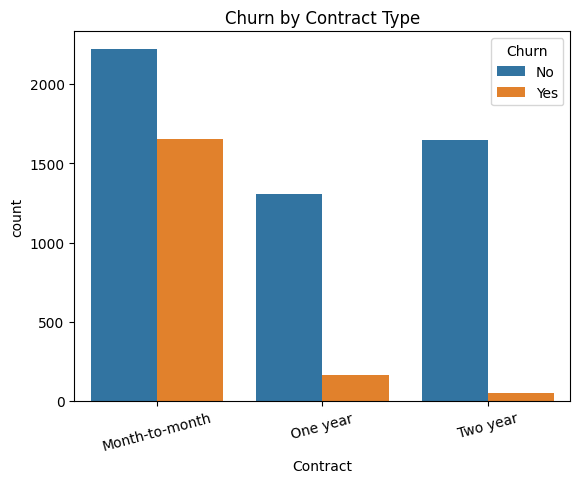

In [ ]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df_original
)

plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

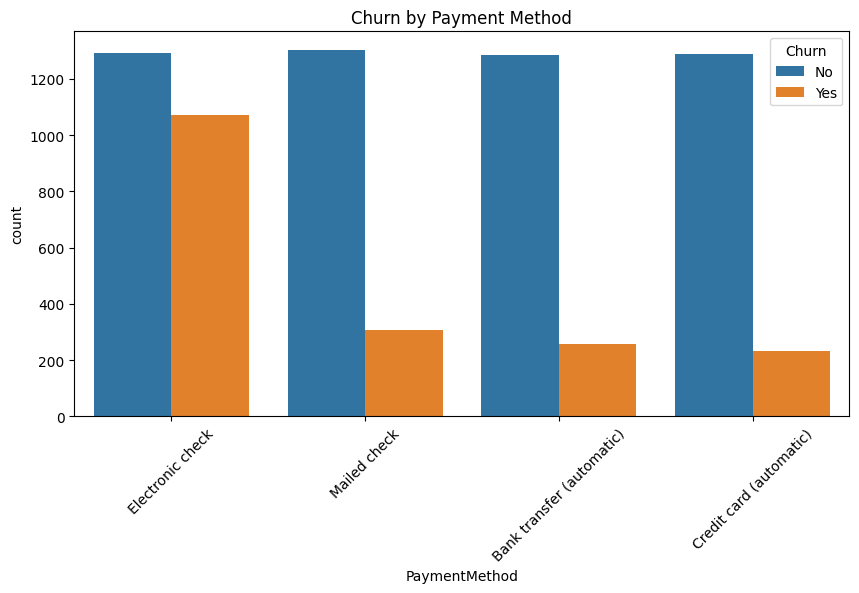

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df_original
)

plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

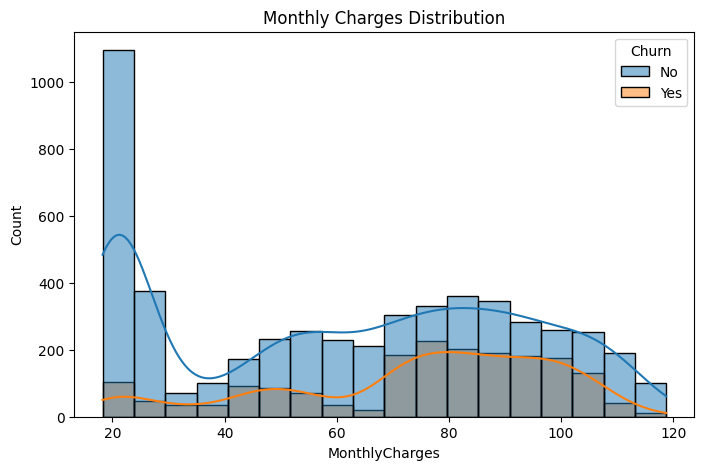

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_original,
    x='MonthlyCharges',
    hue='Churn',
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.show()

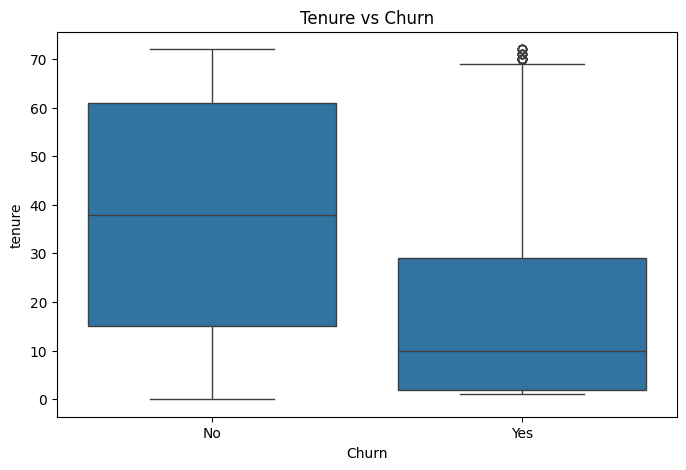

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df_original
)

plt.title("Tenure vs Churn")
plt.show()

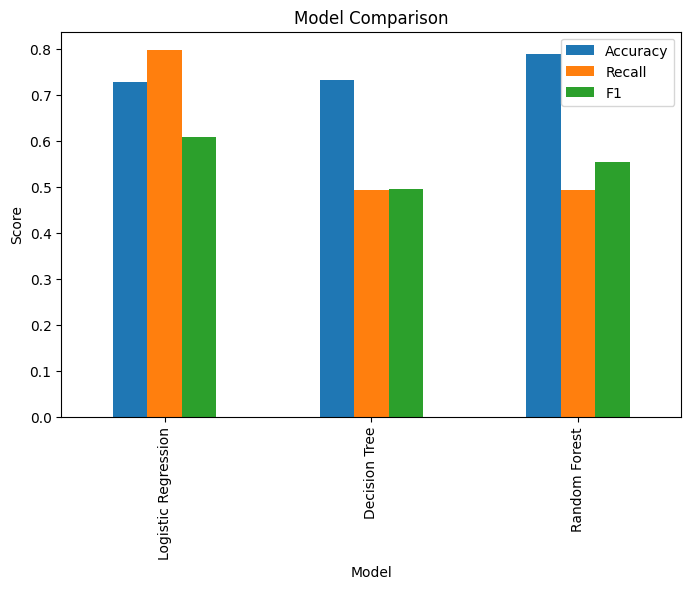

In [ ]:
results_df.plot(
    x='Model',
    y=['Accuracy','Recall','F1'],
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

In [ ]:
import pandas as pd

# ---- STEP 1: Load raw SAP export ----
df = pd.read_csv("DTL_Dispatch_Report.csv")

# ---- STEP 2: Isolate the deliveries that are stuck (not fully loaded, not untouched) ----
partial = df[df["Delivery_Loading_Status"] == "Partial Completed"]
pending_deliveries = set(partial["externalOrderId"])

# ---- STEP 3: Find the HUs still blocking those deliveries ----
blocking = df[
    (df["externalOrderId"].isin(pending_deliveries)) &
    (df["hu_status"] != "LOADED")
]

# ---- STEP 4: Build HU -> {deliveries it unblocks} map ----
hu_to_deliveries = blocking.groupby("Handling_Unit")["externalOrderId"].apply(set).to_dict()

# ---- STEP 5: Greedy Minimum Set Cover ----
remaining = set(pending_deliveries)
selected_hus = []

while remaining:
    # pick the HU that covers the MOST still-open deliveries
    best_hu, best_cover = None, set()
    for hu, delivs in hu_to_deliveries.items():
        cover = delivs & remaining
        if len(cover) > len(best_cover):
            best_hu, best_cover = hu, cover
    if not best_hu:
        break  # nothing left to cover
    selected_hus.append(best_hu)
    remaining -= best_cover

# ---- STEP 6: Output ----
result = pd.DataFrame({"Recommended_HU": selected_hus})
result.to_excel("Minimum_HU_Set_Result.xlsx", index=False)

print(f"Deliveries needing closure: {len(pending_deliveries)}")
print(f"Minimum HUs to load: {len(selected_hus)}")